# LuxNLP Demo Notebook (Poster / Meeting)

This notebook gives a **short end-to-end demo** of the LuxNLP pipeline:

1. **Data sources** (Wikidata, LOD.lu, Leipzig corpora)
2. **Dataset** in **CoNLL BIO** format
3. **Quick stats** and **label distribution**
4. **Model inference demo** (XLM-RoBERTa fine-tuned for NER)
5. **Evaluation on DEV/TEST** + simple visualization
6. **Preliminary conclusions** (what works / what to improve)

> Tip for A0 poster: run all cells and export key plots as images.

In [1]:
pip install -U transformers datasets accelerate torch seqeval scikit-learn


Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path

# --- find repo root automatically ---
ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent  # if you're inside scripts/

DATA_DIR  = ROOT / "data" / "processed" / "ner_splits_balanced"
DEV_CONLL  = DATA_DIR / "dev.conll"
TEST_CONLL = DATA_DIR / "test.conll"

# MODEL_DIR = ROOT / "models" / "lux_ner_xlmr" / "checkpoint-2000"  # change if needed
MODEL_DIR = ROOT / "models" / "xlmr_ner_v3" / "checkpoint-7000"  # change if needed

print("ROOT:", ROOT)
print("DEV :", DEV_CONLL)
print("TEST:", TEST_CONLL) 
print("MODEL:", MODEL_DIR)

assert DEV_CONLL.exists(), f"Missing: {DEV_CONLL}"
assert TEST_CONLL.exists(), f"Missing: {TEST_CONLL}"
assert MODEL_DIR.exists(), f"Missing: {MODEL_DIR}"


ROOT: d:\DOWNLOADS\BRAVE\LuxNLP
DEV : d:\DOWNLOADS\BRAVE\LuxNLP\data\processed\ner_splits_balanced\dev.conll
TEST: d:\DOWNLOADS\BRAVE\LuxNLP\data\processed\ner_splits_balanced\test.conll
MODEL: d:\DOWNLOADS\BRAVE\LuxNLP\models\xlmr_ner_v3\checkpoint-7000


In [3]:
# === 1) Read CoNLL (token tag) + basic stats ===
from typing import List, Tuple
from collections import Counter

def read_conll(path: Path) -> List[List[Tuple[str, str]]]:
    sents, cur = [], []
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                if cur:
                    sents.append(cur)
                    cur = []
                continue
            parts = line.split()
            if len(parts) < 2:
                continue
            token = " ".join(parts[:-1])
            tag = parts[-1]
            cur.append((token, tag))
    if cur:
        sents.append(cur)
    return sents

dev_sents = read_conll(DEV_CONLL)
test_sents = read_conll(TEST_CONLL)

print("DEV sentences:", len(dev_sents))
print("TEST sentences:", len(test_sents))

def conll_stats(sents):
    tok = 0
    tag_counts = Counter()
    lens = []
    for s in sents:
        lens.append(len(s))
        for _, t in s:
            tok += 1
            tag_counts[t] += 1
    return tok, lens, tag_counts

dev_tok, dev_lens, dev_tags = conll_stats(dev_sents)
test_tok, test_lens, test_tags = conll_stats(test_sents)

print("\nDEV tokens:", dev_tok, "avg_len:", sum(dev_lens)/len(dev_lens))
print("TEST tokens:", test_tok, "avg_len:", sum(test_lens)/len(test_lens))
print("\nTop DEV tags:", dev_tags.most_common(10))

DEV sentences: 5331
TEST sentences: 5333

DEV tokens: 107009 avg_len: 20.072969424123055
TEST tokens: 106521 avg_len: 19.973935870991937

Top DEV tags: [('O', 99576), ('B-MEDICINE', 3729), ('I-PER', 1690), ('B-PER', 1425), ('B-PRODUCT', 162), ('B-DATE', 146), ('B-LOC', 120), ('B-EVENT', 62), ('I-LOC', 29), ('I-ORG', 20)]


In [4]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


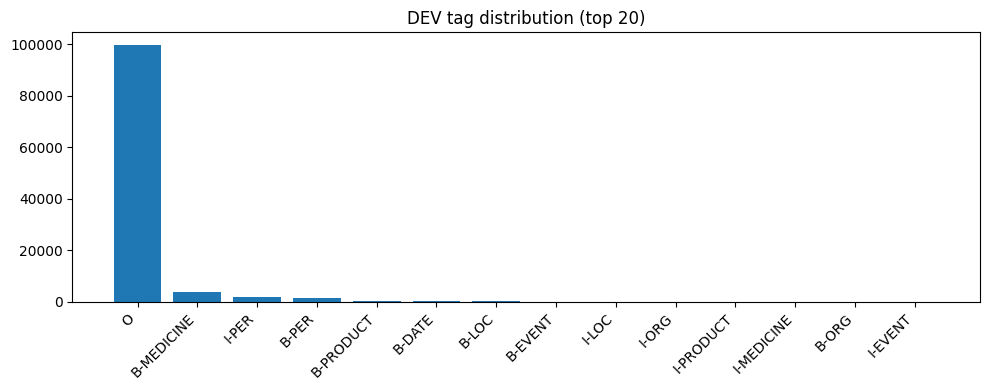

In [5]:
# === 2) Visualize label distribution (DEV) ===
import matplotlib.pyplot as plt

def plot_top_tags(tag_counts, title, top_n=20):
    items = tag_counts.most_common(top_n)
    labels = [k for k,_ in items]
    values = [v for _,v in items]
    plt.figure(figsize=(10,4))
    plt.bar(labels, values)
    plt.xticks(rotation=45, ha="right")
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_top_tags(dev_tags, "DEV tag distribution (top 20)")

## Quick context (for poster)

**NER labels covered:**
- Standard: **PER, LOC, ORG, DATE**
- New: **MEDICINE, PRODUCT, EVENT**

**Why XLM-RoBERTa?**
- Luxembourgish is **low-resource**
- XLM-R transfers multilingual knowledge (DE/FR/EN) and works well with subwords.

In [6]:
# === 3) Load model + tokenizer ===
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModelForTokenClassification

tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR, use_fast=True)
model = AutoModelForTokenClassification.from_pretrained(MODEL_DIR)
model.eval()

id2label = model.config.id2label
if any(isinstance(k, str) for k in id2label.keys()):
    id2label = {int(k): v for k, v in id2label.items()}
label2id = {v:k for k,v in id2label.items()}

print("Num labels:", len(id2label))
print("Labels:", list(id2label.values()))

d:\DOWNLOADS\BRAVE\LuxNLP\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
The tokenizer you are loading from 'd:\DOWNLOADS\BRAVE\LuxNLP\models\xlmr_ner_v3\checkpoint-7000' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


Num labels: 14
Labels: ['B-DATE', 'B-EVENT', 'B-LOC', 'B-MED', 'B-MISC', 'B-ORG', 'B-PER', 'I-EVENT', 'I-LOC', 'I-MED', 'I-MISC', 'I-ORG', 'I-PER', 'O']


In [7]:
# === 4) Demo: run NER on custom Luxembourgish sentences ===
def predict_ner(text: str):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=128)
    with torch.no_grad():
        out = model(**inputs)
    pred_ids = out.logits.argmax(dim=-1)[0].tolist()
    toks = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

    words = []
    current_word = ""
    current_tag = None

    for tok, pid in zip(toks, pred_ids):
        if tok in tokenizer.all_special_tokens:
            continue
        tag = id2label[pid]

        if tok.startswith("▁"):
            if current_word:
                words.append((current_word, current_tag))
            current_word = tok[1:]
            current_tag = tag
        else:
            current_word += tok
            if current_tag == "O" and tag != "O":
                current_tag = tag

    if current_word:
        words.append((current_word, current_tag))
    return words

examples = [
    "Jean ass Dokter zu Lëtzebuerg an schafft bei Amazon.",

]

for txt in examples:
    print("\nTEXT:", txt)
    preds = predict_ner(txt)
    for w, t in preds:
        print(f"  {w:20s} {t}")


TEXT: Jean ass Dokter zu Lëtzebuerg an schafft bei Amazon.
  Jean                 B-PER
  ass                  O
  Dokter               B-MED
  zu                   O
  Lëtzebuerg           O
  an                   O
  schafft              O
  bei                  O
  Amazon.              O


In [8]:
# === 5) Evaluate on DEV/TEST (seqeval if available; else token accuracy) ===
from transformers import DataCollatorForTokenClassification, Trainer, TrainingArguments
from datasets import Dataset, DatasetDict

def conll_to_hf(sentences):
    tokens, tags = [], []
    for sent in sentences:
        t, y = zip(*sent)
        tokens.append(list(t))
        tags.append(list(y))
    return Dataset.from_dict({"tokens": tokens, "ner_tags": tags})

def align_labels_with_tokens(labels, word_ids, label2id):
    aligned = []
    prev = None
    for wid in word_ids:
        if wid is None:
            aligned.append(-100)
        else:
            lab = labels[wid]
            if wid == prev and lab.startswith("B-"):
                lab = "I-" + lab[2:]
            aligned.append(label2id.get(lab, label2id.get("O", 0)))
        prev = wid
    return aligned

dev_ds = conll_to_hf(dev_sents)
test_ds = conll_to_hf(test_sents)
datasets = DatasetDict(validation=dev_ds, test=test_ds)

def tokenize_and_align(examples):
    tok = tokenizer(examples["tokens"], is_split_into_words=True, truncation=True, max_length=128)
    new_labels = []
    for i, labels in enumerate(examples["ner_tags"]):
        wids = tok.word_ids(batch_index=i)
        new_labels.append(align_labels_with_tokens(labels, wids, label2id))
    tok["labels"] = new_labels
    return tok

tokenized = datasets.map(tokenize_and_align, batched=True, remove_columns=["tokens", "ner_tags"])
collator = DataCollatorForTokenClassification(tokenizer)

trainer = Trainer(
    model=model,
    args=TrainingArguments(output_dir="tmp_eval", per_device_eval_batch_size=32, report_to=[]),
    tokenizer=tokenizer,
    data_collator=collator,
)

def compute_metrics_seqeval(pred_ids, label_ids):
    y_true, y_pred = [], []
    for p, l in zip(pred_ids, label_ids):
        sent_true, sent_pred = [], []
        for pi, li in zip(p, l):
            if li == -100:
                continue
            sent_true.append(id2label[li])
            sent_pred.append(id2label[pi])
        y_true.append(sent_true)
        y_pred.append(sent_pred)

    try:
        from seqeval.metrics import precision_score, recall_score, f1_score, classification_report
        return {
            "precision": float(precision_score(y_true, y_pred)),
            "recall": float(recall_score(y_true, y_pred)),
            "f1": float(f1_score(y_true, y_pred)),
            "report": classification_report(y_true, y_pred, digits=4)
        }
    except Exception as e:
        correct = 0
        total = 0
        for yt, yp in zip(y_true, y_pred):
            for a, b in zip(yt, yp):
                total += 1
                correct += int(a == b)
        return {"token_accuracy": correct / total if total else 0.0, "note": f"seqeval not available: {e}"}

def eval_split(name):
    out = trainer.predict(tokenized[name])
    pred = np.argmax(out.predictions, axis=-1)
    return compute_metrics_seqeval(pred, out.label_ids)

dev_metrics = eval_split("validation")
test_metrics = eval_split("test")

print("DEV metrics:", {k:v for k,v in dev_metrics.items() if k != "report"})
print("TEST metrics:", {k:v for k,v in test_metrics.items() if k != "report"})

if "report" in test_metrics:
    print("\nPer-class report (TEST):\n")
    print(test_metrics["report"])

Map: 100%|██████████| 5333/5333 [00:01<00:00, 4321.36 examples/s]
C:\Users\yashg\AppData\Local\Temp\ipykernel_24412\333538792.py:43: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
d:\DOWNLOADS\BRAVE\LuxNLP\.venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


DEV metrics: {'token_accuracy': 0.9661188099720406, 'note': "seqeval not available: No module named 'seqeval'"}
TEST metrics: {'token_accuracy': 0.966063118017862, 'note': "seqeval not available: No module named 'seqeval'"}


In [9]:
# === 6) Visualize PRF (if available) ===
import matplotlib.pyplot as plt

def show_prf(metrics, title):
    if not all(k in metrics for k in ("precision","recall","f1")):
        print("No PRF metrics available. ->", metrics)
        return
    vals = [metrics["precision"], metrics["recall"], metrics["f1"]]
    labels = ["precision","recall","f1"]
    plt.figure(figsize=(5,3))
    plt.bar(labels, vals)
    plt.ylim(0,1.0)
    plt.title(title)
    plt.tight_layout()
    plt.show()

show_prf(dev_metrics, "DEV: Precision / Recall / F1")
show_prf(test_metrics, "TEST: Precision / Recall / F1")

No PRF metrics available. -> {'token_accuracy': 0.9661188099720406, 'note': "seqeval not available: No module named 'seqeval'"}
No PRF metrics available. -> {'token_accuracy': 0.966063118017862, 'note': "seqeval not available: No module named 'seqeval'"}
